# A Trilha Acadêmica
__Objetivo__: Elaborar um notebook didático que aborde o tema "Redes neurais informadas por física (PINN)", apresentando exemplo de aplicação e discussão acerca do desempenho.

**Disciplina**: Redes Neurais e Algorítimos Genéticos

**Professor**: Daniel R. Cassar

**Aluno**: Joaquim Júnior Ferola Fonseca

**Ilum Escola de Ciências**

# Recapitulação

### O que é uma rede neural

Uma rede neural [1] é um modelo de aprendizado de máquina inspirado no funcionamento do cérebro humano. 
Sua unidade fundamental são os neurônios artificiais, estruturas que recebem dados de entrada,processam eles por meio de cálculos matemáticos e retornam um dado de saída.

Tal qual o cérebro humano, ela é composta por diversos neurônios, que se organizam em três tipos de camadas: entrada, ocultas e saída. Os dados entram pela camada de entrada, passam por uma ou mais camadas ocultas, em que são processados, e geram um resultado na camada de saída. 

Cada neurônio processa a informação obtida multiplicando cada dado de entrada por um peso, somando-os, adicionando um viés e aplicando uma função de ativação. Durante o treinamento de uma rede neural, os pesos e viéses são ajustados sucessivamente de modo a minimizar a discrepância entre os dados reais e os dados gerados pelo modelo. Esse erro é representado por uma função de perda, para o caso mais simples, o erro quadrático entre predição e valor real, o que pode ser escrito como:

$$
F_{loss} = (u_{real}(x) - u_{rede}(x))^2
$$

Existem diferentes técnicas de treinamento para o ajuste dos parâmetros de uma rede. A mais simples delas é a descida do gradiente, em que se calcula a derivada parcial da função de perda em relação a cada parâmetro da rede. Essa informação revela a forma com que o parâmetro contribui para o erro da rede (se ele aumenta o erro, se ele o diminui, e em que medida isso acontece) e a partir dela o parâmetro é levemente ajustado a fim de minimizar esse erro. Mais especificamente, se um parâmetro apresenta gradiente positivo, ele é diminuido, se apresenta gradiente negativo, ele é aumentado, se o gradiente é baixo, muda-se pouco o parâmetro, e se é alto muda-se muito. Isso pode ser feito de maneira simples subtraindo o produto entre o gradiente e uma taxa de aprendizado do valor de cada parâmetro.

$$
\theta \rightarrow \theta - \eta \times \frac{\partial F_{loss}}{\partial \theta}
$$

Em uma análise matemática, redes neurais atuam como aproximadores de funções. Isso é o que permite que elas extraiam padrões e prevejam resultados aproximados sem que seja necessário conhecer forma analítica da função desejada. Essa é uma ferramenta poderosa tanto para a matemática quanto para ciência de dados e apresentam diversas aplicações no meio científico. 

### O que são MLPs

Multi-Layer Perceptrons (MLPs) [2] são redes neurais compostas por uma camada de entrada, múltiplas camadas ocultas e uma camada de saida, de modo que cada neurônio recebe como entrada os dados saida de todos os neurônios da camada anterior. 

O treinamento de uma MLP (usando o método de descida do gradiente) acontece em 5 etapas:

1.  **Forward pass**: os dados são processados pela rede e retornam uma previsão.

2.  **Loss**: cálcula-se a função de perda que será minimizada.

3.  **Zerar o gradiente**: o valor de todos os gradientes são zerados.

4.  **Backpropagation**: todos os gradientes são calculados.

5.  **Atualização dos parâmetros**: modifica-se cada peso e viés da rede neural levando em consideração o seu gradiente local e a taxa de aprendizado.

# A limitação das redes neurais

Uma grande limitação envolvendo redes neurais é que elas aprendem apenas apartir dos dados fornecidos. Isso significa que as leis físicas não são consideradas durante o treinamento de uma rede, de modo que o modelo possa gerar predições que violam leis físicas fundamentais, como conservação de energia ou princípios termodinâmicos, sem nenhuma restrição.

Essa situação se torna ainda mais agravante para os casos em que os dados experimentais são escassos ou ruidosos. Devido a falta de informações, a rede não tem informação e não consegue generalizar corretamente para regiões do domínio não cobertas pelos dados. Ainda que haja conhecimentos físicos sobre o comportamento da função, que ajudem a generalizar esse comportamento, redes neurais comuns não são capazes de aproveitar desse conhecimento prévio sobre o problema.

Vamos testar na pratica essa limitação de redes neurais tentando resolver um problema físico por meio de uma MLP. O problema em questão será o oscilador harmônico simples.

### Treinando uma MLP para solucionar um problema físico

#### 1. O oscilador harmônico simples

Oscilador harmônico [3] é um sistema conhecido da física clássica que, quando deslocado de sua posição de equilíbrio, sofre uma força restauradora F proporcional ao deslocamento x. Isso gera um movimento repetitivo regular em torno do ponto de equilibrio, com amplitude e frequência constantes.

A equação diferencial que rege esse sistema é:

$$
\frac{d^2x}{dt^2} + \omega_0^2x = 0
$$

Sendo $x$ a posição, $t$ o tempo e $\omega_0$ a frequência.

Nosso objetivo será desenvolver uma rede neural capaz de resolver esse problema. Contudo, a solução dessa equação é conhecida, portanto podemos usar essa informação para analisar o desempenho da nossa rede neural. A solução da equação assume a forma da combinação linear entre senos e cossenos:

$$
x = A\cos(\omega t) + B\sin(\omega t)
$$

Em que $A$ é a amplitude do movimento e $\phi$ a fase inicial.

Vamos considerar para esse exercício também que conhecemos as condições iniciais do sistema e que elas são: $x(0) = 1$, $\frac{dx}{dt}(0) = 0$ e $\omega = 2\pi$

Substituindo nas equações obtemos 

$$
x(0) = A\cancel{\cos(0)} + \cancel{B\sin(0)}
$$
$$
A = 1
$$
$$
\frac{dx}{dt}(0) = \cancel{-A\sin(0)} + B\cancel{\cos(0)}
$$
$$
B = 0
$$

Ou seja, a solução analítica do problema é: 
$$
x = \cos(2\pi t)
$$

Segue a representação visual dessa solução:

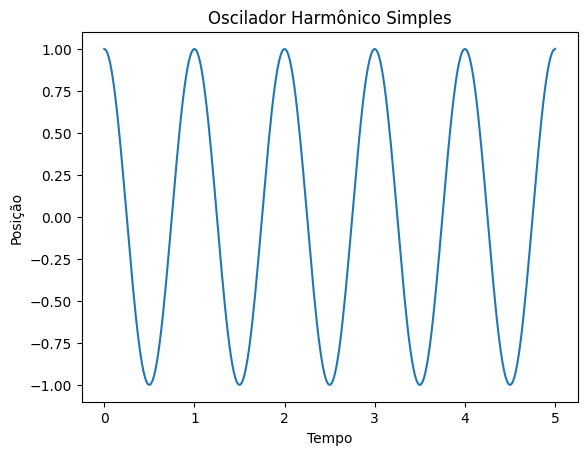

In [1]:
import matplotlib.pyplot as plt
import torch

omega = 2 * torch.pi
t = torch.linspace(0, 5, 300).unsqueeze(1)
x = torch.cos(omega*t)

plt.figure()
plt.plot(t, x)
plt.title("Oscilador Harmônico Simples")
plt.xlabel("Tempo")
plt.ylabel("Posição")
plt.show()

#### 2. Implementando a MLP

Vamos agora treinar uma MLP com o objetivo de resolver esse problema.

Para implementar uma MLP precisamos primeiro gerar os dados utilizados pelo modelo. Primeiramente, analisaremos dados igualmente espaçados e exatos. Para isso, basta definir os valores de t e calcular os respectivos valores de x.

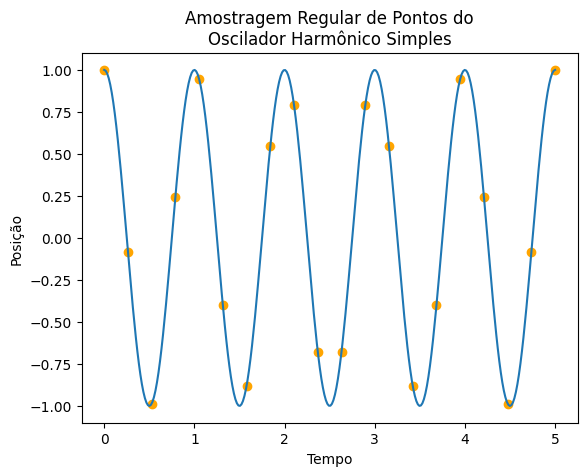

In [2]:
t_train_r = torch.linspace(0, 5, 20).unsqueeze(1) 
x_train_r = torch.cos(omega * t_train_r)

plt.figure()
plt.plot(t, x)
plt.scatter(t_train_r, x_train_r, c="orange")
plt.title("""Amostragem Regular de Pontos do
Oscilador Harmônico Simples""")
plt.xlabel("Tempo")
plt.ylabel("Posição")
plt.show()

Para organizar o fluxo de dados durante o treinamento, utilizamos um LightningDataModule [5]. Essa classe é responsável por encapsular toda a lógica de carregamento e fornecimento de dados para o modelo, separando essa responsabilidade da arquitetura da rede em si. 

Ele é composto por duas funções: setup e train_dataloader.

A função setup é responsável por converter os dados para tensores. No nosso caso, ela não é estritamente necessária pois os dados sinteticos foram produzindo usando o módulo torch e já possuem esse formato. Contudo, ela foi mantida pelo propósito didático de explicitar o formato necessário e para que a classe não dependa desse cuidado prévio do usuário.

Em problemas típicos, o setup também realiza a divisão dos dados em conjuntos de treino, validação e teste. Porém, no nosso caso isso não é necessário pois os dados de treino são gerados sinteticamente e os dados de teste são a própria solução analítica.

Já a função train_dataloader fornece os dados de treino para a MLP em lotes (batchs) para que MLP possa fazer o forward_pass e calcular o gradiente. Como possuimos poucos pontos, todos os dados são fornecidos simultaneamente para o treinamento. Também utilizamos aqui shuffle=True para que a ordem dos pontos seja embaralhada e o modelo não aprenda a ordem dos deles ao invés do padrão.


In [ ]:
import torch.nn as nn
import torch.optim as optim
import lightning as L
L.seed_everything(31415)
from torch.utils.data import DataLoader, TensorDataset

class DataModule(L.LightningDataModule):
    def __init__(self, t_train, x_train, tamanho_lote=20):
        super().__init__()
        self.t_train = t_train
        self.x_train = x_train
        self.tamanho_lote = tamanho_lote

    def setup(self, stage=None):
        self.t_train = torch.tensor(self.t_train, dtype=torch.float32).view(-1, 1)
        self.x_train = torch.tensor(self.x_train, dtype=torch.float32).view(-1, 1)

    def train_dataloader(self):
        return DataLoader(
            TensorDataset(self.t_train, self.x_train),
            batch_size=self.tamanho_lote,
            shuffle=True,
        )

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


Com isso, podemos criar a arquitetura da rede. Ela é definida pela função Sequential e será composta de 3 camadas ocultas com 128 neurônios cada, recebendo um atributo (o tempo) e retornando um target (a posição). A função de ativação escolhida foi a tangente hiperbólica (Tanh), pois ela possui derivada bem definida, e a função de perda é o erro quadrático médio (MSE).

A classe MLP também posusi as funções responsáveis por fazer o passar os dados pela rede (forward) e realizar todas as etapas do treinamento (training_step). Além disso, foi utilizado o otimizador Adam [6], que modifica a forma com que os parâmetros são ajustados. Ao invés de considerar unicamente o valor do gradiente, ele também possui dois coeficientes, o momento, que permite que o peso continue convergindo em uma direção apesar dos possíveis ruidos, e a média móvel dos quadrados, que adapta a taxa de aprendizado conforme as modificações anteriores (uma maior taxa aos que modificaram pouco, e uma maior taxa aos que modificaram muito). Essas duas caracteristicas muitas vezes conferem ao Adam uma grande eficiencia para convergir a um problema, por isso escolhemos ele para a nossa MLP.

In [4]:
class MLP(L.LightningModule):
    def __init__(self, taxa_aprendizado=1e-3):
        super().__init__()
        self.taxa_aprendizado = taxa_aprendizado

        self.camadas = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.fun_perda = nn.MSELoss()

    def forward(self, t):
        return self.camadas(t)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.taxa_aprendizado)

    def training_step(self, batch, batch_idx):
        t, x = batch
        x_pred = self(t)
        loss = self.fun_perda(x_pred, x)
        self.log("loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

Com tudo pronto, basta fazer o treinamento utilizando a função Trainer

In [5]:
dm_r = DataModule(t_train_r, x_train_r)

modelo_mlp_r = MLP(taxa_aprendizado=1e-3)

treinador_r = L.Trainer(
    max_epochs=5000,
    enable_progress_bar=True,
    logger=True,
    enable_checkpointing=False
)

treinador_r.fit(modelo_mlp_r, dm_r)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\2635122341.py:15: UserWarning: To copy construct from a tensor, it is recommended to 

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ camadas   │ Sequential │ 33.4 K │ train │     0 │
│ 1 │ fun_perda │ MSELoss    │      0 │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=5000` reached.


Com isso, calculamos a métrica do desempenho utilizando como base o RMSE e plotamos os resultados para a visualização. Além disso, plotamos também a evolução da loss ao longo do treinamento da rede, dado que fica armazenado no CSV metrics ao fim do treinamento da rede.

O RMSE do modelo MLP foi de 0.10280363261699677 unidades de x.


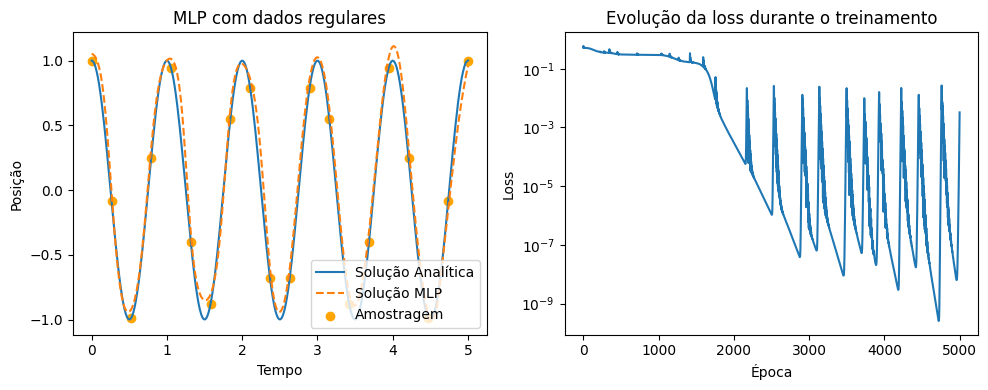

In [46]:
from sklearn.metrics import root_mean_squared_error

modelo_mlp_r.eval()
with torch.no_grad():
    x_pred_r = modelo_mlp_r(t)

RMSE_r = root_mean_squared_error(x, x_pred_r)

print(f"O RMSE do modelo MLP foi de {RMSE_r} unidades de x.")

import pandas as pd

df_loss_r = pd.read_csv(f"{treinador_r.logger.log_dir}/metrics.csv")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(t, x, label="Solução Analítica")
axs[0].plot(t, x_pred_r, label="Solução MLP", linestyle="--")
axs[0].scatter(t_train_r, x_train_r, c="orange", label="Amostragem")
axs[0].set_title("MLP com dados regulares")
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("Posição")
axs[0].legend(loc="lower right")

axs[1].plot(df_loss_r["epoch"], df_loss_r["loss"])
axs[1].set_yscale("log")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Loss")
axs[1].set_title("Evolução da loss durante o treinamento")

plt.tight_layout()
plt.show()

É possível notar que a MLP realizou uma aproximação razoávle da função quando utilizamos dados regulares: a frequência foi respeitada, e o RMSE do modelo foi baixo. Contudo, é possível notar algumas imperfeições quanto a amplitude da onda e o próprio formato das ondas possui uma leve inconsistência.

Agora, vamos analisar o que acontece se utilizamos dados com espaçamentos aleatórios e ruido. Para isso, basta selecionar valores aleatórios para t e calcular seu respectivo valor de x.

Um detalhe aqui é que, pelo nosso entendimento do problema, temos conhecimento das condições iniciais, em especial $x(0) = 1$, então é justo que o ponto (0, 1) esteja dentre os dados que conferimos à rede. Para os pontos regularmente espaçados, ele estava presente de forma automática, mas para pontos irregulares, é necessário adicioná-lo mecanicamente.

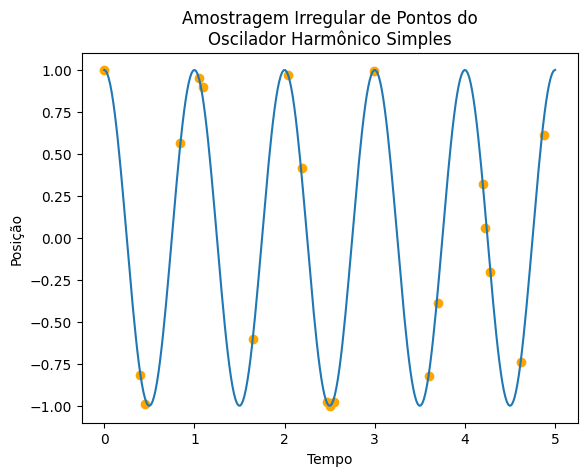

In [7]:
torch.manual_seed(31415)

t_train_i = torch.rand(19, 1) * 5     
x_train_i = torch.cos(omega * t_train_i) + 0.05 * torch.randn(19, 1)

t_ic = torch.tensor([[0.0]])
x_ic = torch.tensor([[1.0]])

t_train_i = torch.cat([t_train_i, t_ic], dim=0)
x_train_i = torch.cat([x_train_i, x_ic], dim=0)

plt.figure()
plt.plot(t, x)
plt.scatter(t_train_i, x_train_i, c="orange")
plt.title("""Amostragem Irregular de Pontos do
Oscilador Harmônico Simples""")
plt.xlabel("Tempo")
plt.ylabel("Posição")
plt.show()

Treinando o modelo para os dados irregulares, obtemos:

In [8]:
dm_i = DataModule(t_train_i, x_train_i)

modelo_mlp_i = MLP(taxa_aprendizado=1e-3)

treinador_i = L.Trainer(
    max_epochs=5000,
    enable_progress_bar=True,
    logger=True,
    enable_checkpointing=False,
)

treinador_i.fit(modelo_mlp_i, dm_i)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\2635122341.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.t_train = torch.tensor(self.t_train, dtype=torch.float32).view(-1, 1)
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\2635122341.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x_train = torch.tensor(self.x_train, dtype=torch.float32).view(-1, 1)

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ camadas   │ Sequential │ 33.4 K │ train │     0 │
│ 1 │ fun_perda │ MSELoss    │      0 │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=5000` reached.


O RMSE do modelo MLP foi de 0.17330217361450195 unidades de x.


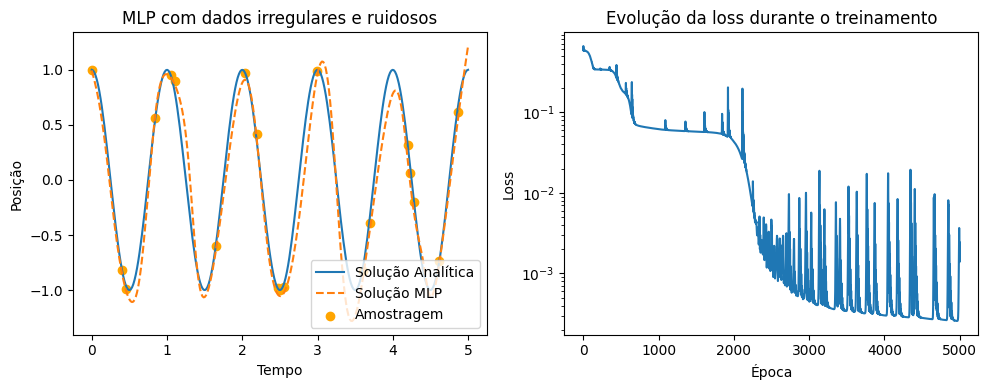

In [47]:
from sklearn.metrics import root_mean_squared_error

modelo_mlp_i.eval()
with torch.no_grad():
    x_pred_i = modelo_mlp_i(t)

RMSE_i = root_mean_squared_error(x, x_pred_i)

print(f"O RMSE do modelo MLP foi de {RMSE_i} unidades de x.")

df_loss_i = pd.read_csv(f"{treinador_i.logger.log_dir}/metrics.csv")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(t, x, label="Solução Analítica")
axs[0].plot(t, x_pred_i, label="Solução MLP", linestyle="--")
axs[0].scatter(t_train_i, x_train_i, c="orange", label="Amostragem")
axs[0].set_title("MLP com dados irregulares e ruidosos")
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("Posição")
axs[0].legend(loc="lower right")

axs[1].plot(df_loss_i["epoch"], df_loss_i["loss"])
axs[1].set_yscale("log")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Loss")
axs[1].set_title("Evolução da loss durante o treinamento")

plt.tight_layout()
plt.show()

Conforme discutido anteriormente, a MLP de fato apresentou maior dificuldade na previsão de dados na presença de intervalos irregulares e com ruido. Regiões com muitos dados nos pontos máximos e mínimos dos picos tiveram uma amplitude mais constante, mas o formato da onda se tornou mais irregular, resultando em um RMSE maior.

Outro detalhe acerca de MLPs é a dificuldade de extrapolar o modelo para as regiões sem dados, vamos analisar como está o comportamento da função para $t>5$

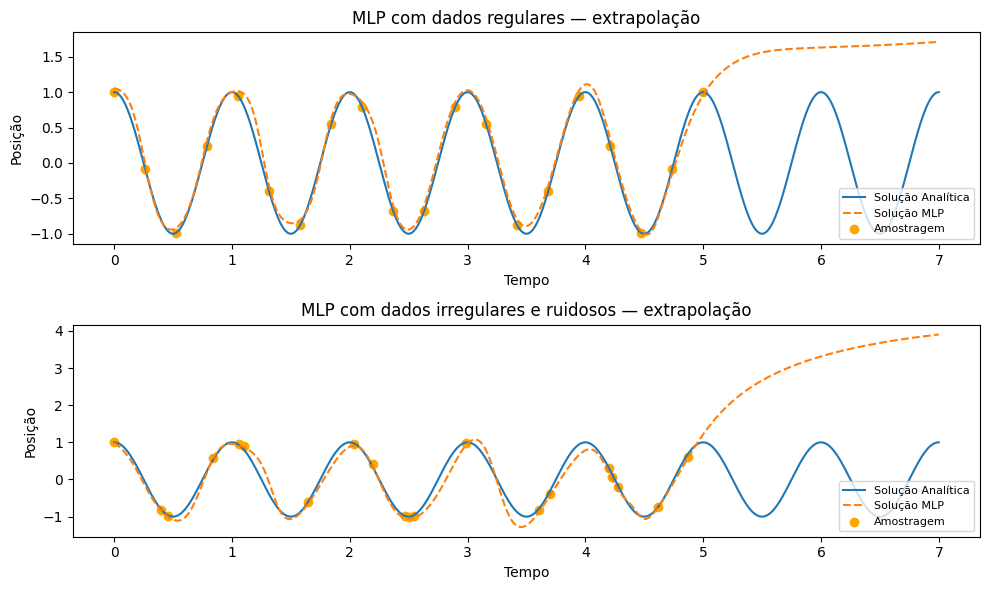

In [34]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6))

t_extrapolado = torch.linspace(0, 7, 1000).unsqueeze(1)
x_extrapolado = torch.cos(omega*t_extrapolado)

with torch.no_grad():
    x_pred_r = modelo_mlp_r(t_extrapolado)
with torch.no_grad():
    x_pred_i = modelo_mlp_i(t_extrapolado)

axs[0].plot(t_extrapolado, x_extrapolado, label="Solução Analítica")
axs[0].plot(t_extrapolado, x_pred_r, label="Solução MLP", linestyle="--")
axs[0].scatter(t_train_r, x_train_r, c="orange", label="Amostragem")
axs[0].set_title("MLP com dados regulares — extrapolação")
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("Posição")
axs[0].legend(loc="lower right", fontsize=8)

axs[1].plot(t_extrapolado, x_extrapolado, label="Solução Analítica")
axs[1].plot(t_extrapolado, x_pred_i, label="Solução MLP", linestyle="--")
axs[1].scatter(t_train_i, x_train_i, c="orange", label="Amostragem")
axs[1].set_title("MLP com dados irregulares e ruidosos — extrapolação")
axs[1].set_xlabel("Tempo")
axs[1].set_ylabel("Posição")
axs[1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Como podemos observar, a MLP não é capaz de extrapolar os resultados para as regiões além do domínio em que foi treinada, pois não possui nenhuma informação acerca do comportamento que deveria assumir nessas posições.

# Physics-Informed Neural Network - PINN

A fim de contornar essa limitação, em 2019 M. Raissi e P. Perdikaris [6] desenvolveram um novo tipo de rede neural, as Physics-Informed Neural Network (PINN). A ideia por trás desse tipo de rede é: "e se, além de minimizar o erro nos dados, a gente também punisse a rede quando ela viola a equação diferencial?". Essa é uma estratégia que permite unir os dados presentes ao conhecimento físico, promovendo um treinamento mais preciso da rede neural.[7]

Vamos ver agora como realizar isso na prática

### A função de perda

A nossa ideia é penalizar a rede sempre que ela violar a equação diferencial. Portanto, essa violação deve ser considerada na função de perda. Além disso, também temos conhecimento das condições de contorno, portanto elas também deve ser consideradas.

Para isso, a nossa função de perda passa a ser composta pela soma ponderada entre 3 funções de perda diferentes: a perda do dados, a perda da equação diferencial e a perda da condição inicial.

$$
F_{loss} = \lambda_d F_{loss-dados} + \lambda_{e} F_{loss-EDO} + \lambda_i F_{loss-inicial}
$$

#### 1. A função de perda para os dados

A função de perda para os dados continua sendo a mesma que utilizamos para a MLP: o MSE. Na MLP, o MSE foi definido pela função nn.MSELoss(), mas ela também pode ser facilmente definida em python como a média do erro quadrado de cada ponto em relação à predição do modelo.

$$
F_{loss-dados} = \frac{1}{N} \sum^N_{i=1}​(x(t_i​)−u(t_i)​)^2
$$

In [11]:
def loss_dados(modelo, t_train, x_train):
    "Calcula a média do erro quadrático do modelo em relação aos dados"
    x_pred = modelo(t_train)
    loss = torch.mean((x_pred - x_train)**2)
    return loss

#### 2. A função de perda para a EDO

A função de perda da nossa EDO se baseia no conhecimento de que

$$
\frac{d^2x}{dt^2} + \omega_0^2x = 0
$$

Portanto, se $\frac{d^2x}{dt^2} + \omega_0^2x \neq 0$, valor de $\frac{d^2x}{dt^2} + \omega_0^2x$ é chamado de resíduo, e pode ser utilizado para indicar o quanto a rede neural está violando a equação física.

$$
F_{loss-EDO} = \frac{1}{N} \sum^N_{i=1}​(\frac{d^2x}{dt^2} + \omega_0^2x​)^2
$$

Contudo, a implementação dessa loss em python é levemente diferente da anterior, pois nesse caso precisamos do valor da segunda derivada do modelo no ponto. Para isso, podemos usar a função torch.autograd.grad(), que calcula automaticamente essa derivada. Essa função recebe como argumentos a função derivada e a variavél referente a quem a função está sendo derivada, o grad_outputs que informa os pesos para a soma dos gradientes calculados (no nosso caso 1 para todos os pontos) e o create_graph = True que indica para manter o grafo criado no calculo da derivada (o que é importante para que seja possível calcular a segunda derivada).

Outro cuidado também necessário é os pontos no qual essa loss atua. No caso da loss baseada nos dados, ela atua somente onde possui dados, pois caso contrário ela não possui um refencial para realizar o calculo do erro. No caso da loss da EDO, ela atua em todos os pontos, pois tem-se conhecimento da derivada da rede neural em todo o seu domínio. Esses pontos em que essa loss é medida são chamadas de collocation points, portanto usaremos o dominio t_colloc ao ínves do domínio t_train para essa loss.

In [12]:
def loss_edo(modelo, t_colloc, omega):
    "Calcula a média do erro quadrático do modelo em relação à EDO"
    x = modelo(t_colloc)

    dx = torch.autograd.grad(
        x, t_colloc,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
    )[0]

    d2x = torch.autograd.grad(
        dx, t_colloc,
        grad_outputs=torch.ones_like(dx),
        create_graph=True,
    )[0]

    residuo = d2x + omega**2 * x
    loss = torch.mean(residuo**2)
    return loss

#### 3. A função de perda para as condições iniciais

Para as condições iniciais,o erro associado também será o erro quadrático, para mantermos a mesma dimensionalidade. Como sabemos que $x(0) = 1$ e que $\frac{dx}{dt} = 0$, as loss functions serão:  $(u(0) - x(0))^2$ e $(\frac{du}{dt}(0) - \frac{dx}{dt}(0))^2$. Somando ambas e substituindo os valores definidos na condição de contorno, obtemos:

$$
F_{loss-inicial} = \frac{1}{2}\left[(u(0) - 1)^2 + \left(\frac{du}{dt}(0) - 0\right)^2\right]
$$

Como na própria definição indica, essa loss é analisada apenas no ponto inicial (t=0), que será representado aqui como t_ic.

Essa mesma lógica pode ser aplicada caso o problema seja multidimensional e utilize de condições de contorno ao invés de condições iniciais, basta calcular a média do erro quadrático em relação às condições definidas e utilizá-la como loss.

In [13]:
def loss_condicao_inicial(modelo, t_ic):
    "Calcula o erro quadrático do modelo em relação à cada uma das condições iniciais"
    x0 = modelo(t_ic)

    dx0 = torch.autograd.grad(
        x0, t_ic,
        grad_outputs=torch.ones_like(x0),
        create_graph=True,
    )[0]

    loss_x0 = (x0 - 1.0)**2
    loss_dx0 = (dx0 - 0.0)**2
    loss = torch.mean(torch.cat([loss_x0, loss_dx0]))
    return loss

#### 4. A função de perda da PINN

Com as 3 funções de perda, podemos montar a função de perda total para a PINN. Ela será a soma ponderada das 3 contribuições (dados, EDO e condições iniciais), para que o modelo busque uma solução que satisfaça simultaneamente a equação do oscilador harmônico e a as medições disponíveis.

$$
F_{loss} = \lambda_d F_{loss-dados} + \lambda_{e} F_{loss-EDO} + \lambda_i F_{loss-inicial}
$$

Os pesos $\lambda$ definem a importancia relativa de cada termo. Como a loss da EDO poussi uma maior ordem de grandeza em relação às demais, será atribuido um peso menor a ela afim de equilibrar as contribuições.

In [14]:
def loss_pinn(modelo, t_train, x_train, t_colloc, t_ic, omega,
               lambda_d=1.0, lambda_e=1.0, lambda_i=1.0):

    L_d = loss_dados(modelo, t_train, x_train)
    L_edo = loss_edo(modelo, t_colloc, omega)
    L_ic = loss_condicao_inicial(modelo, t_ic)

    return lambda_d * L_d + lambda_e * L_edo + lambda_i * L_ic

### Implementação

Visto que a PINN altera apenas a função de perda, existe total liberdade na criação da arquitetura da rede neural. Para compararmos com o desempenho da MLP anterior, usaremos a mesma arquitetura e os mesmos dados. Dessa forma, a implementação continuará a mesma que já foi realizada alterando apenas a função de perda e adicionando todos os seus parâmetros ao DataModule.

In [15]:
class PINN_DataModule(L.LightningDataModule):
    def __init__(self, t_train, x_train, tamanho_lote=20):
        super().__init__()
        self.t_train = t_train
        self.x_train = x_train
        self.tamanho_lote = tamanho_lote

    def setup(self, stage=None):
        self.t_train = torch.tensor(self.t_train, dtype=torch.float32).view(-1, 1)
        self.x_train = torch.tensor(self.x_train, dtype=torch.float32).view(-1, 1)

    def train_dataloader(self):
        return DataLoader(
            TensorDataset(self.t_train, self.x_train),
            batch_size=self.tamanho_lote,
            shuffle=True,
        )

In [16]:
class PINN(L.LightningModule):
    def __init__(self, t_colloc, t_ic, omega, taxa_aprendizado=1e-3,
                 lambda_d=1.0, lambda_e=1.0, lambda_i=1.0):
        super().__init__()
        self.t_colloc = t_colloc
        self.t_ic = t_ic
        self.omega = omega
        self.taxa_aprendizado = taxa_aprendizado
        self.lambda_d = lambda_d
        self.lambda_e = lambda_e
        self.lambda_i = lambda_i

        self.camadas = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.fun_perda = loss_pinn

    def forward(self, t):
        return self.camadas(t)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.taxa_aprendizado)

    def training_step(self, batch, batch_idx):
        t_train, x_train = batch
        t_colloc = self.t_colloc.requires_grad_(True)
        t_ic = self.t_ic.requires_grad_(True)
        loss = self.fun_perda(self, t_train, x_train, t_colloc, t_ic, self.omega,
               self.lambda_d, self.lambda_e, self.lambda_i)
        self.log("loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

Vamos analisar o desempenho da PINN tanto para os dados regulares quanto para os dados irregulares. Como os pontos já estão definidos, precisamos apenas definir t_colloc e t_ic

In [17]:
t_colloc = torch.linspace(0, 5, 300).unsqueeze(1).requires_grad_(True)
t_ic = torch.tensor([0.0]).requires_grad_(True)

Vamos analisar agora o desempenho da pinn para dados regulares. Um detalhe sobre as PINN é que por possuírem uma função de ativação mais complexa, normalmente elas são mais custosas computacionalmente e necessitam de um maior número de épocas para convergir. Portanto, usaremos uma taxa de aprendizado maior (0.01) e 7500 épocas.

In [41]:
pinn_dm_r = PINN_DataModule(t_train_r, x_train_r)

modelo_pinn_r = PINN(t_colloc, t_ic, omega, lambda_d=10, lambda_e=0.1, lambda_i=1, taxa_aprendizado=1e-2)

treinador_pinn_r = L.Trainer(
    max_epochs=7500,
    enable_progress_bar=True,
    logger=True,
    enable_checkpointing=False
)

treinador_pinn_r.fit(modelo_pinn_r, pinn_dm_r)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.t_train = torch.tensor(self.t_train, dtype=torch.float32).view(-1, 1)
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x_train = torch.tensor(self.x_train, dtype=torch.float32).view(-1, 1)


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ camadas │ Sequential │ 33.4 K │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=7500` reached.


O RMSE do modelo PINN foi de 0.07629183679819107 unidades de x.


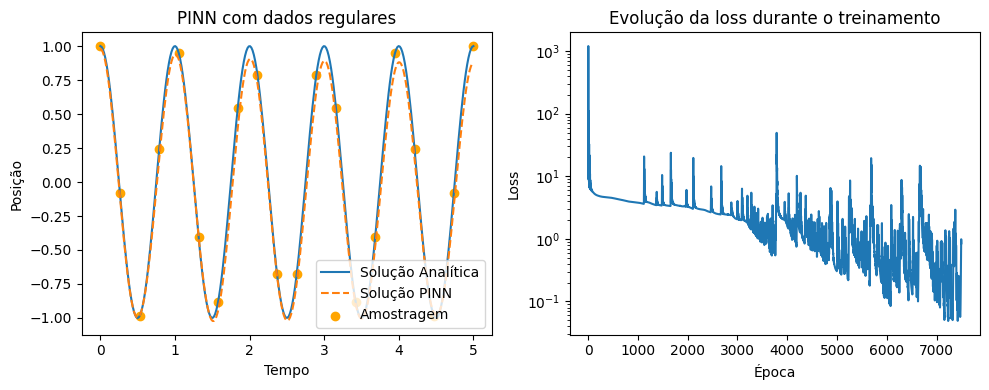

In [48]:
from sklearn.metrics import root_mean_squared_error

modelo_pinn_r.eval()
with torch.no_grad():
    x_pred_pinn_r = modelo_pinn_r(t)

RMSE_pinn_r = root_mean_squared_error(x, x_pred_pinn_r)

print(f"O RMSE do modelo PINN foi de {RMSE_pinn_r} unidades de x.")

df_loss_pinn_r = pd.read_csv(f"{treinador_pinn_r.logger.log_dir}/metrics.csv")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(t.detach().numpy(), x, label="Solução Analítica")
axs[0].plot(t.detach().numpy(), x_pred_pinn_r, label="Solução PINN", linestyle="--")
axs[0].scatter(t_train_r, x_train_r, c="orange", label="Amostragem")
axs[0].set_title("PINN com dados regulares")
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("Posição")
axs[0].legend(loc="lower right")

axs[1].plot(df_loss_pinn_r["epoch"], df_loss_pinn_r["loss"])
axs[1].set_yscale("log")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Loss")
axs[1].set_title("Evolução da loss durante o treinamento")
plt.tight_layout()
plt.show()

Podemos ver que a PINN apresentou uma forma bem mais consistente, apresentando dificulade apenas em manter a amplitude da onda

Em seguida, faremos o mesmo para dados irregulares

In [43]:
pinn_dm_i = PINN_DataModule(t_train_i, x_train_i)

modelo_pinn_i = PINN(t_colloc, t_ic, omega, lambda_d=10, lambda_e=0.1, lambda_i=1, taxa_aprendizado=1e-2)

treinador_pinn_i = L.Trainer(
    max_epochs=7500,
    enable_progress_bar=True,
    logger=True,
    enable_checkpointing=False
)

treinador_pinn_i.fit(modelo_pinn_i, pinn_dm_i)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.t_train = torch.tensor(self.t_train, dtype=torch.float32).view(-1, 1)
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x_train = torch.tensor(self.x_train, dtype=torch.float32).view(-1, 1)


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ camadas │ Sequential │ 33.4 K │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=7500` reached.


O RMSE do modelo PINN foi de 0.15893308818340302 unidades de x.


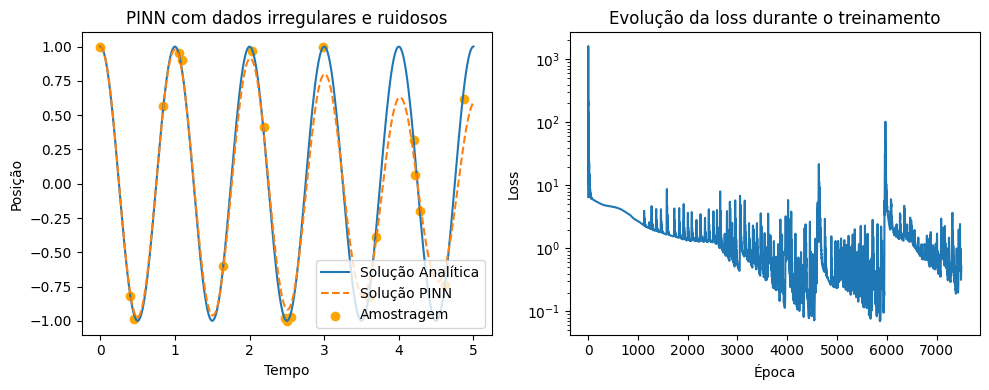

In [44]:
from sklearn.metrics import root_mean_squared_error

modelo_pinn_i.eval()
with torch.no_grad():
    x_pred_pinn_i = modelo_pinn_i(t)

RMSE_pinn_i = root_mean_squared_error(x, x_pred_pinn_i)

print(f"O RMSE do modelo PINN foi de {RMSE_pinn_i} unidades de x.")

df_loss_pinn_i = pd.read_csv(f"{treinador_pinn_i.logger.log_dir}/metrics.csv")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(t.detach().numpy(), x, label="Solução Analítica")
axs[0].plot(t.detach().numpy(), x_pred_pinn_i, label="Solução PINN", linestyle="--")
axs[0].scatter(t_train_i, x_train_i, c="orange", label="Amostragem")
axs[0].set_title("PINN com dados irregulares e ruidosos")
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("Posição")
axs[0].legend(loc="lower right")

axs[1].plot(df_loss_pinn_i["epoch"], df_loss_pinn_i["loss"])
axs[1].set_yscale("log")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Loss")
axs[1].set_title("Evolução da loss durante o treinamento")

plt.tight_layout()
plt.show()

Podemos ver que a PINN para dados irregulares apresentou ainda mais dificuldade em manter a amplitude correta, dada a falta de dados nos picos de ondas. Contudo, o RMSE do modelo ainda foi melhor do que o RMSE da MLP para os mesmos dados

Vamos analisar agora a capacidade de extrapolação da PINN. Diferentemente de uma MLP, a PINN é capaz de ajustar seus parâmetros mesmo em regiões com ausência de dados, pois é capaz de se guiar pela equação diferêncial. Portanto, realizamos o treinamento da PINN utilizando o t_colloc como todo o domínio no qual analizaremos o desempenho da rede.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.t_train = torch.tensor(self.t_train, dtype=torch.float32).view(-1, 1)
C:\Users\joaquim25018\AppData\Local\Temp\ip

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ camadas │ Sequential │ 33.4 K │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=5000` reached.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ camadas │ Sequential │ 33.4 K │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=5000` reached.


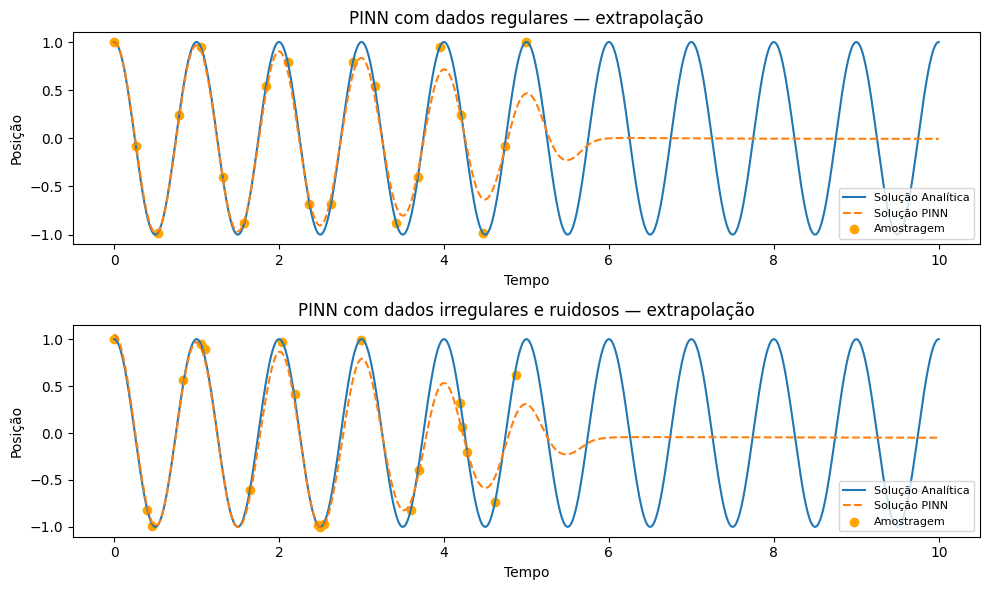

In [ ]:
t_extrapolado = torch.linspace(0, 10, 1000).unsqueeze(1)
x_extrapolado = torch.cos(omega*t_extrapolado)

modelo_pinn_extrapolado_r = PINN(t_extrapolado, t_ic, omega, lambda_d=10, lambda_e=0.1, lambda_i=1, taxa_aprendizado=1e-2)
modelo_pinn_extrapolado_i = PINN(t_extrapolado, t_ic, omega, lambda_d=10, lambda_e=0.1, lambda_i=1, taxa_aprendizado=1e-2)


treinador_pinn_extrapolado_r = L.Trainer(
    max_epochs=5000,
    enable_progress_bar=True,
    logger=True,
    enable_checkpointing=False
)

treinador_pinn_extrapolado_i = L.Trainer(
    max_epochs=5000,
    enable_progress_bar=True,
    logger=True,
    enable_checkpointing=False
)

treinador_pinn_extrapolado_r.fit(modelo_pinn_extrapolado_r, pinn_dm_r)
treinador_pinn_extrapolado_i.fit(modelo_pinn_extrapolado_i, pinn_dm_i)

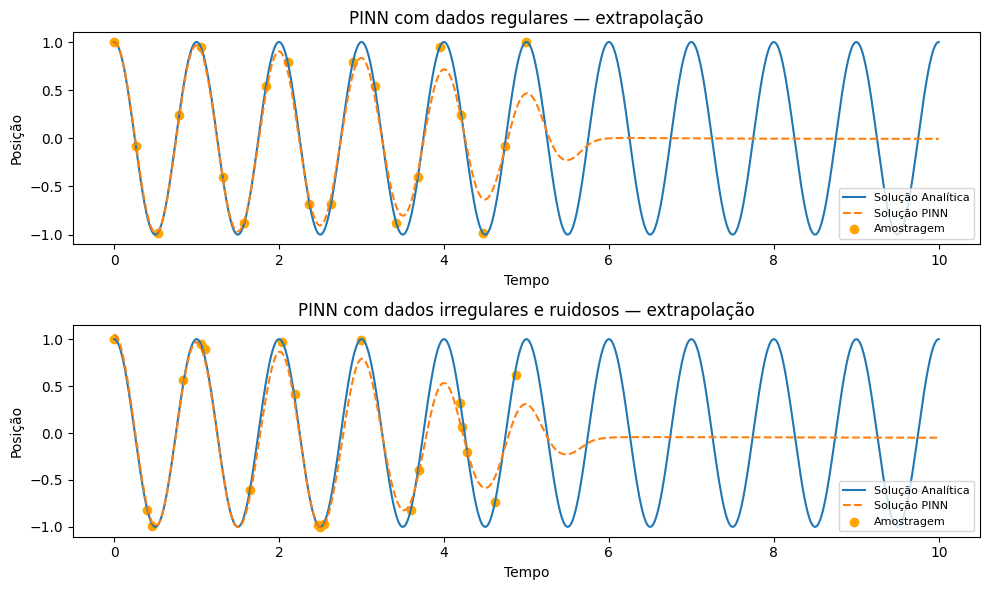

In [33]:
with torch.no_grad():
    x_pred_pinn_extrapolado_r = modelo_pinn_extrapolado_r(t_extrapolado)
with torch.no_grad():
    x_pred_pinn_extrapolado_i = modelo_pinn_extrapolado_i(t_extrapolado)

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

axs[0].plot(t_extrapolado.detach().numpy(), x_extrapolado, label="Solução Analítica")
axs[0].plot(t_extrapolado.detach().numpy(), x_pred_pinn_extrapolado_r, label="Solução PINN", linestyle="--")
axs[0].scatter(t_train_r, x_train_r, c="orange", label="Amostragem")
axs[0].set_title("PINN com dados regulares — extrapolação")
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("Posição")
axs[0].legend(loc="lower right", fontsize=8)

axs[1].plot(t_extrapolado.detach().numpy(), x_extrapolado, label="Solução Analítica")
axs[1].plot(t_extrapolado.detach().numpy(), x_pred_pinn_extrapolado_i, label="Solução PINN", linestyle="--")
axs[1].scatter(t_train_i, x_train_i, c="orange", label="Amostragem")
axs[1].set_title("PINN com dados irregulares e ruidosos — extrapolação")
axs[1].set_xlabel("Tempo")
axs[1].set_ylabel("Posição")
axs[1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Nesse caso, podemos observar um fenômeno relacionado à natureza do problema escolhido. Uma vez que $x(t) = 0$ é uma solução para a EDO, na ausência de dados para moldar o comportamento cossenoide, a função assume essa resolução e mantém-se constante. Por isso, ela apresenta um comportamento amortecido e assume $x(t)=0$ para $t>6$

Em problemas como o resfriamento de Newton, em que há apenas uma solução, isso não é um problema, e a rede apresenta uma melhor capacidade de extrapolação.

Isso mostra que a multiplicidade de soluções deve ser levada em consideração para o treinamento de uma PINN

# Resolvendo um problema inverso por PINN

PINN capaz de resolver o oscilador harmônico respeitando tanto os dados observados quanto a física do sistema. Isso é o que chamamos de problema direto: encontrar a solução x(t) tendo conhecimento sobre a equação diferencial e todos os seus parâmetros.

Contudo, muitas vezes nós não temos total conhecimento dos parâmetros da função. Vamos imaginar que nós não conhecemos o valor do parâmetro $\omega$ da equação do oscilador harmônico, resolver essa EDO por PINN seria o que chamamos de problema inverso: a partir dos dados observados, descobrir os parâmetros que governam o sistema. [8]

$$
\frac{d^2x}{dt^2} + \omega^2x = 0,    \omega = ?
$$

Nesse caso, $\omega$ se torna um parâmetro da rede, tal qual os pesos e vieses da MLP, que são ajustados durante o treinamento. Para implementar isso, basta definir $\omega$ como um nn.Parameter [9] na arquitetura da rede, recebendo como argumento um tensor com o chute inicial.

In [23]:
class PINN_Inversa(L.LightningModule):
    def __init__(self, t_colloc, t_ic, taxa_aprendizado=1e-3,
                 lambda_d=1.0, lambda_e=1.0, lambda_i=1.0):
        super().__init__()
        self.t_colloc = t_colloc
        self.t_ic = t_ic
        self.omega = nn.Parameter(torch.tensor([1.0]))
        self.taxa_aprendizado = taxa_aprendizado
        self.lambda_d = lambda_d
        self.lambda_e = lambda_e
        self.lambda_i = lambda_i

        self.camadas = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.fun_perda = loss_pinn

    def forward(self, t):
        return self.camadas(t)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.taxa_aprendizado)

    def training_step(self, batch, batch_idx):
        t_train, x_train = batch
        t_colloc = self.t_colloc.requires_grad_(True)
        t_ic = self.t_ic.requires_grad_(True)
        loss = self.fun_perda(self, t_train, x_train, t_colloc, t_ic, self.omega,
               self.lambda_d, self.lambda_e, self.lambda_i)
        self.log("loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

Com isso feito, basta treinar a rede normalmente e o parâmetro será armazenado no atributo omega do modelo treinado, podendo ser obtido por modelo.omega.item()

In [ ]:
pinn_inversa_dm_r = PINN_DataModule(t_train_r, x_train_r)

modelo_pinn_inversa_r = PINN_Inversa(t_colloc, t_ic, lambda_d=10, lambda_e=0.1, lambda_i=1, taxa_aprendizado=1e-2)

treinador_pinn_inversa_r = L.Trainer(
    max_epochs=5000,
    enable_progress_bar=True,
    logger=True,
    enable_checkpointing=False
)

treinador_pinn_inversa_r.fit(modelo_pinn_inversa_r, pinn_inversa_dm_r)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.t_train = torch.tensor(self.t_train, dtype=torch.float32).view(-1, 1)
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x_train = torch.tensor(self.x_train, dtype=torch.float32).view(-1, 1)


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ camadas      │ Sequential │ 33.4 K │ train │     0 │
│   │ other params │ n/a        │      1 │ n/a   │   n/a │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=5000` reached.


ω verdadeiro:    6.2832
ω descoberto:    6.1982
Erro relativo:   1.35%
O RMSE do modelo PINN foi de 0.1323227882385254 unidades de x.


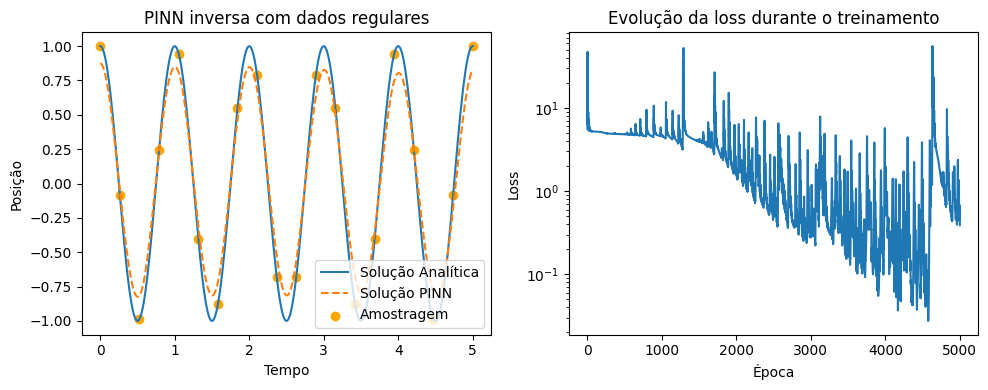

In [50]:
omega_pinn_inversa = modelo_pinn_inversa_r.omega.item()
print(f"ω verdadeiro:    {omega:.4f}")
print(f"ω descoberto:    {omega_pinn_inversa:.4f}")
print(f"Erro relativo:   {abs(omega_pinn_inversa - omega) / omega * 100:.2f}%")

modelo_pinn_inversa_r.eval()
with torch.no_grad():
    x_pred_pinn_inversa_r = modelo_pinn_inversa_r(t)

RMSE_pinn_inversa_r = root_mean_squared_error(x, x_pred_pinn_inversa_r)

print(f"O RMSE do modelo PINN foi de {RMSE_pinn_inversa_r} unidades de x.")

df_loss_pinn_inversa_r = pd.read_csv(f"{treinador_pinn_inversa_r.logger.log_dir}/metrics.csv")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(t.detach().numpy(), x, label="Solução Analítica")
axs[0].plot(t.detach().numpy(), x_pred_pinn_inversa_r, label="Solução PINN", linestyle="--")
axs[0].scatter(t_train_r, x_train_r, c="orange", label="Amostragem")
axs[0].set_title("PINN inversa com dados regulares")
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("Posição")
axs[0].legend(loc="lower right")

axs[1].plot(df_loss_pinn_inversa_r["epoch"], df_loss_pinn_inversa_r["loss"])
axs[1].set_yscale("log")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Loss")
axs[1].set_title("Evolução da loss durante o treinamento")

plt.tight_layout()
plt.show()

Podemos ver que a rede foi capaz de obter o coeficinete com alta precisão, havendo um erro relativo de apenas 1.35%. Isso mostra que a PINN possui grande potêncial na determinação de parâmetros físicos desconhecidos em EDOs e EDPs.

Vejamos também o desempenho da PINN reversa para dados irregulares e ruidosos

In [26]:
pinn_inversa_dm_i = PINN_DataModule(t_train_i, x_train_i)

modelo_pinn_inversa_i = PINN_Inversa(t_colloc, t_ic, lambda_d=10, lambda_e=0.1, lambda_i=1, taxa_aprendizado=1e-2)

treinador_pinn_inversa_i = L.Trainer(
    max_epochs=5000,
    enable_progress_bar=True,
    logger=True,
    enable_checkpointing=False
)

treinador_pinn_inversa_i.fit(modelo_pinn_inversa_i, pinn_inversa_dm_i)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.t_train = torch.tensor(self.t_train, dtype=torch.float32).view(-1, 1)
C:\Users\joaquim25018\AppData\Local\Temp\ipykernel_31500\1995399702.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x_train = torch.tensor(self.x_train, dtype=torch.float32).view(-1, 1)


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ camadas      │ Sequential │ 33.4 K │ train │     0 │
│   │ other params │ n/a        │      1 │ n/a   │   n/a │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\joaquim25018\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=5000` reached.


ω verdadeiro:    6.2832
ω descoberto:    6.2440
Erro relativo:   0.62%
O RMSE do modelo PINN foi de 0.11425333470106125 unidades de x.


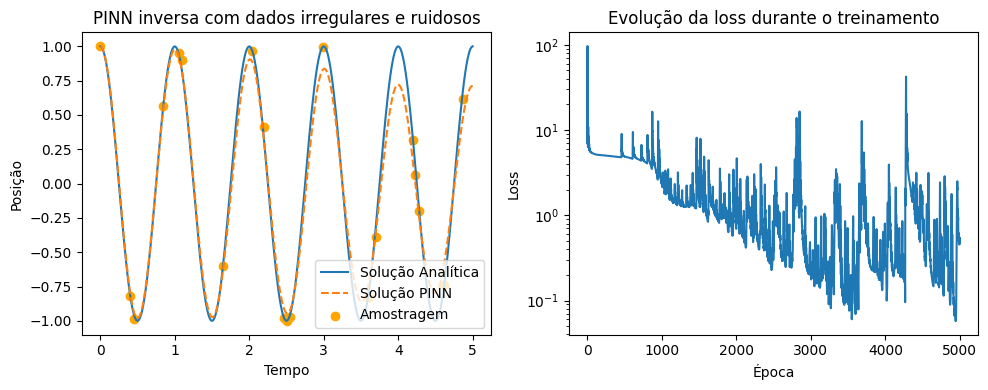

In [51]:
omega_pinn_inversa = modelo_pinn_inversa_i.omega.item()
print(f"ω verdadeiro:    {omega:.4f}")
print(f"ω descoberto:    {omega_pinn_inversa:.4f}")
print(f"Erro relativo:   {abs(omega_pinn_inversa - omega) / omega * 100:.2f}%")

modelo_pinn_inversa_i.eval()
with torch.no_grad():
    x_pred_pinn_inversa_i = modelo_pinn_inversa_i(t)

RMSE_pinn_inversa_i = root_mean_squared_error(x, x_pred_pinn_inversa_i)

print(f"O RMSE do modelo PINN foi de {RMSE_pinn_inversa_i} unidades de x.")

df_loss_pinn_inversa_i = pd.read_csv(f"{treinador_pinn_inversa_i.logger.log_dir}/metrics.csv")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(t.detach().numpy(), x, label="Solução Analítica")
axs[0].plot(t.detach().numpy(), x_pred_pinn_inversa_i, label="Solução PINN", linestyle="--")
axs[0].scatter(t_train_i, x_train_i, c="orange", label="Amostragem")
axs[0].set_title("PINN inversa com dados irregulares e ruidosos")
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("Posição")
axs[0].legend(loc="lower right")


axs[1].plot(df_loss_pinn_inversa_i["epoch"], df_loss_pinn_inversa_i["loss"])
axs[1].set_yscale("log")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Loss")
axs[1].set_title("Evolução da loss durante o treinamento")

plt.tight_layout()
plt.show()

Podemos ver que a PINN apresentou um desempenho ainda maior na presença de dados irregulares. Isso possívelmente se dá pela presença de pontos nos 4 primeiros pontos máximos, o que facilita a rede a entender a periodicidade nos dados.

# Conclusão 

Vamos comparar o desempenho dos diferentes modelos:

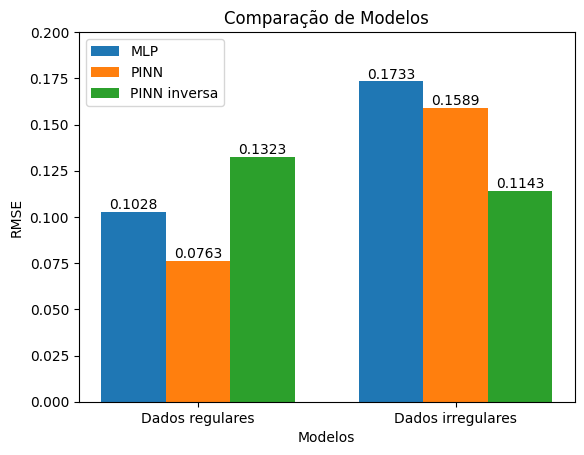

In [74]:
import numpy as np

labels = ["Dados regulares", "Dados irregulares"]

mlp = [RMSE_r, RMSE_i]
pinn = [RMSE_pinn_r, RMSE_pinn_i]
pinn_inversa = [RMSE_pinn_inversa_r, RMSE_pinn_inversa_i]

x = np.arange(len(labels))
largura = 0.25

plt.figure()

barras1 = plt.bar(x - 2*largura/2, mlp, largura, label="MLP")
barras2 = plt.bar(x, pinn, largura, label="PINN")
barras3 = plt.bar(x + 2*largura/2, pinn_inversa, largura, label="PINN inversa")

for barra in barras1+barras2+barras3:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{altura:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(x, labels)

plt.xlabel('Modelos')
plt.ylabel('RMSE')
plt.title('Comparação de Modelos')
plt.ylim((0, 0.2))
plt.legend()

plt.show()

É possível ver que a PINN apresentou um melhor desempenho tanto para os dados regulares quanto para os dados irregulares, e a maioria dos modelos apresentou melhor desempenho com dados regulares. Surpreendentemente, A PINN inversa foi o modelo que apresentou o melhor desempenho para dados irregulares, superando o próprio desempenho para dados regulares. Isso se dá a própria aleatoricidade no treinamento do modelo.

Com isso, é possível analisar que as PINN de fato apresentam um bom desempenho e um grande potêncial na resolução de EDOs e EDPs ainda que não se tenha conhecimento da solução analítica da equação.

# Referências

[1] TECNOLOBLOG. Redes neurais: o que são, tipos, aplicações e como funcionam. Disponível em: https://www.tecnoloblog.com/pt/O-que-s%C3%A3o-redes-neurais/. acesso em: 11 mai. 2025.

[2] GEEKSFORGEEKS. Multi-Layer Perceptron Learning in Tensorflow. Disponível em: https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/. acesso em: 11 mai. 2025.

[3] WIKIPÉDIA. Oscilador harmônico. Disponível em: https://pt.wikipedia.org/wiki/Oscilador_harm%C3%B4nico. acesso em: 11 mai. 2025.

[4] KINGMA, D. P.; BA, J. Adam: A Method for Stochastic Optimization. arXiv, 2014. Disponível em: https://doi.org/10.48550/arXiv.1412.6980.

[5] RAISSI, M.; PERDIKARIS, P.; KARNIADAKIS, G. E. Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. Journal of Computational Physics, v. 378, p. 686–707, 2019. Disponível em: https://www.sciencedirect.com/science/article/pii/S0021999118307125.

[6] MATHWORKS. What Are Physics-Informed Neural Networks (PINNs)? Disponível em: https://www.mathworks.com/discovery/physics-informed-neural-networks.html. acesso em: 11 mai. 2025.

[7] LIGHTNING AI. PyTorch Lightning Documentation. Disponível em: https://lightning.ai/docs/pytorch/stable/. acesso em: 11 mai. 2025.

[8] TOWARDS DATA SCIENCE. Inverse Physics-Informed Neural Net. Disponível em: https://towardsdatascience.com/inverse-physics-informed-neural-net-3b636efeb37e/. acesso em: 11 mai. 2025.

[9] PYTORCH. torch.nn.parameter.Parameter — PyTorch 2.11 documentation. Disponível em: https://docs.pytorch.org/docs/2.11/generated/torch.nn.parameter.Parameter.html. acesso em: 11 mai. 2025.